# QCD Amplitude to Squared Amplitude Ablation


In [1]:
!pip install torch_geometric
#I always forget this :(

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.8 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def setup_environment() -> tuple[Path, Path]:
    input_dir = Path("/kaggle/input")
    working_dir = Path("/kaggle/working")

    if not input_dir.exists():
        input_dir = Path(".")
        working_dir = Path("outputs/kaggle_pi_gnn_amp2sq")

    data_files = list(input_dir.rglob("QCD-2-to-2-diag-TreeLevel-*.txt"))
    if not data_files:
        raise FileNotFoundError(f"Could not find data files matching 'QCD-2-to-2-diag-TreeLevel-*.txt' under {input_dir}.")
    data_dir = data_files[0].parent

    parser_files = list(input_dir.rglob("pi_gnn_amp2sq/parser.py"))
    if not parser_files:
        parser_files = list(input_dir.rglob("src/pi_gnn_amp2sq/parser.py"))
    if parser_files:
        package_root = parser_files[0].parent.parent
        if str(package_root) not in sys.path:
            sys.path.insert(0, str(package_root))
    else:
        src_dir = Path.cwd() / "src"
        if src_dir.exists() and str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))

    working_dir.mkdir(parents=True, exist_ok=True)
    return data_dir, working_dir


data_dir, working_dir = setup_environment()
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (8, 4)
print(f"Data directory: {data_dir}")
print(f"Working directory: {working_dir}")


Data directory: /kaggle/input/datasets/nextsmallestml/qcd-dataset
Working directory: /kaggle/working


## Target Variants

I keep two decoder targets.

- `factorized`: I simplify the squared amplitude using SymPy and write it as `(color_factor)*((numerator)/(denominator))`. The model predicts that full symbolic target autoregressively as one postfix sequence under the physics-informed grammar.
- `raw_string`: I decode the original raw SYMBA squared-amplitude string as a postfix sequence under the same grammar.

The PI-GNN path is a physics-augmented sequence encoder. It reads the bounded raw amplitude string together with canonical global tokens, family-signature tokens, typed term tokens, and skeleton term tokens, and the decoder cross-attends to that fused multi-stream memory. The seq2seq baseline only reads the bounded raw amplitude token sequence.

The symbolic factorisation I use here follows the basis-oriented amplitude literature cited in the observation cell below, especially Dixon (1996), Del Duca-Dixon-Maltoni (1999), Johansson-Ochirov (2015), and Catani (1998).

While examining the dataset, I noticed that many of the target expressions admit substantial algebraic simplification. This motivated me to study a factorized prediction target for squared amplitudes. The underlying factorization idea is well established in scattering-amplitude physics, but, to the best of my knowledge, its use as a decoder-target design for squared-amplitude prediction has not been explored in prior ML work.


## Input Handling

The PI-GNN path is a physics-tagged sequence encoder. It reads the bounded raw amplitude string together with compact canonical global and term-summary tokens inside one enriched source sequence, with section-type embeddings marking the physics annotations. The seq2seq baseline only reads the bounded raw amplitude token sequence.


In [3]:
from statistics import mean

from pi_gnn_amp2sq.config import Amp2SqConfig
from pi_gnn_amp2sq.factorization import (
    TARGET_VARIANT_FACTORIZED,
    TARGET_VARIANT_RAW_STRING,
    factorize_squared_amplitude,
)
from pi_gnn_amp2sq.parser import parse_all_qcd
from pi_gnn_amp2sq.tokenizer import AmplitudeTokenizer
from pi_gnn_amp2sq.train import Amp2SqTrainer

VARIANTS = [('gnn', 'gnn'), ('seq2seq', 'seq2seq')]
TARGET_SPECS = [
    {
        "target_variant": TARGET_VARIANT_FACTORIZED,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
    {
        "target_variant": TARGET_VARIANT_RAW_STRING,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
]
TARGET_SPEC_MAP = {spec["target_variant"]: spec for spec in TARGET_SPECS}
SHARED_SPLIT_SEED = 42
SUMMARY_COLUMNS = [
    "target_variant",
    "variant_name",
    "encoder_variant",
    "max_target_len",
    "split_seed",
    "test_seq_accuracy",
]


def encoded_target_length(expr: str, expression_mode: str) -> int:
    tokenizer = AmplitudeTokenizer(expression_mode=expression_mode)
    length = 2
    for token in tokenizer.tokenize_expr(expr):
        length += 1
    return length


def write_markdown_table(df: pd.DataFrame, path: Path, title: str) -> Path:
    lines = [f"# {title}", ""]
    lines.append("| " + " | ".join(df.columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(df.columns)) + " |")
    for row in df.to_dict(orient="records"):
        rendered = []
        for column in df.columns:
            value = row[column]
            if isinstance(value, float):
                rendered.append(f"{value:.3f}")
            else:
                rendered.append(str(value))
        lines.append("| " + " | ".join(rendered) + " |")
    path.write_text("\n".join(lines) + "\n")
    return path


def target_length_stats(current_data_dir: Path | str, target_variant: str) -> dict[str, float]:
    spec = TARGET_SPEC_MAP[target_variant]
    diagrams = parse_all_qcd(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=target_variant)
        for diagram in diagrams
    ]
    lengths = [
        encoded_target_length(target.sequence_target_text(), spec["decoder_representation"])
        for target in targets
    ]
    return {
        "target_variant": target_variant,
        "decoder_representation": spec["decoder_representation"],
        "min": min(lengths),
        "avg": round(mean(lengths), 2),
        "max": max(lengths),
        "max_with_margin": max(lengths) + 16,
    }


def build_example_tables(current_data_dir: Path | str) -> tuple[pd.DataFrame, pd.DataFrame]:
    diagram = parse_all_qcd(current_data_dir)[0]
    raw_squared = diagram.raw_squared
    factorized_target = factorize_squared_amplitude(
        raw_squared,
        target_variant=TARGET_VARIANT_FACTORIZED,
    )
    factorization_example = pd.DataFrame(
        [
            {
                "color_factor": getattr(factorized_target, "color_factor"),
                "denominator": factorized_target.denominator.replace("**", "^"),
                "numerator": factorized_target.numerator_infix,
                "factorized_sequence": factorized_target.full_infix,
                "raw_string": factorized_target.raw_string,
            }
        ]
    )

    representation_examples = []
    for spec in TARGET_SPECS:
        target = factorize_squared_amplitude(
            raw_squared,
            target_variant=spec["target_variant"],
        )
        representation_examples.append(
            {
                "target_variant": spec["target_variant"],
                "decoder_representation": spec["decoder_representation"],
                "use_grammar": spec["use_grammar"],
                "sequence_target": target.sequence_target_text(),
            }
        )
    return factorization_example, pd.DataFrame(representation_examples)


def observation_summary(current_data_dir: Path | str) -> pd.DataFrame:
    diagrams = parse_all_qcd(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=TARGET_VARIANT_FACTORIZED)
        for diagram in diagrams
    ]
    factors = sorted({getattr(target, "color_factor") for target in targets})
    denominators = sorted({target.denominator.replace("**", "^") for target in targets})
    return pd.DataFrame(
        [
            {
                "num_samples": len(targets),
                "unique_color_factors": len(factors),
                "unique_denominators": len(denominators),
            }
        ]
    )


def build_variant_config(
    current_data_dir: Path,
    current_working_dir: Path,
    *,
    target_variant: str,
    variant_name: str,
    encoder_variant: str,
    max_target_len: int,
):
    spec = TARGET_SPEC_MAP[target_variant]
    config = Amp2SqConfig()
    config.data.data_dir = str(current_data_dir)
    config.data.target_variant = target_variant
    config.output_dir = str(current_working_dir / target_variant / variant_name)
    config.experiment_name = f"{target_variant}_{variant_name}"

    config.training.max_epochs = 500 if target_variant == TARGET_VARIANT_RAW_STRING else 250
    config.training.stop_on_val_exact = None
    config.training.stop_on_test_exact = None
    config.training.batch_size = 8
    config.training.learning_rate = 3e-4
    config.training.weight_decay = 1e-5
    config.training.warmup_epochs = 10
    config.training.min_lr = 1e-6
    config.training.gradient_clip = 1.0
    config.training.seed = SHARED_SPLIT_SEED
    config.training.num_workers = 2
    config.training.log_every_n_steps = 10

    config.model.hidden_dim = 192
    config.model.stream_dim = 128
    config.model.graph_dim = 192
    config.model.num_mp_layers = 4
    config.model.num_heads = 8
    config.model.dropout = 0.1
    config.model.max_src_term_len = 192
    config.model.max_src_terms = 32
    config.model.max_flat_src_len = 3072
    config.model.max_tgt_seq_len = max_target_len
    config.model.max_gen_len = max_target_len
    config.model.dec_d_model = 384
    config.model.dec_nhead = 8
    config.model.dec_layers = 6
    config.model.dec_dim_ff = 1024
    config.model.decoder_representation = spec["decoder_representation"]
    config.model.use_grammar = spec["use_grammar"]
    config.model.encoder_variant = encoder_variant
    return config


def _clean_curve(values):
    return [float("nan") if value is None else float(value) for value in values]


def plot_suite_losses(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "loss_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["train_loss"]) + 1))
        ax.plot(epochs, _clean_curve(history["train_loss"]), label="train loss")
        ax.plot(epochs, _clean_curve(history["val_loss"]), label="val loss")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_loss_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def plot_suite_accuracies(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "accuracy_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["val_seq_accuracy"]) + 1))
        ax.plot(epochs, _clean_curve(history["val_seq_accuracy"]), label="val seq accuracy")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation sequence accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_accuracy_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def run_suite(target_variant: str) -> tuple[pd.DataFrame, dict[str, dict]]:
    target_len = max(target_length_stats(data_dir, target_variant)["max_with_margin"], 128)
    results = []
    histories = {}
    for variant_name, encoder_variant in VARIANTS:
        config = build_variant_config(
            data_dir,
            working_dir,
            target_variant=target_variant,
            variant_name=variant_name,
            encoder_variant=encoder_variant,
            max_target_len=target_len,
        )
        trainer = Amp2SqTrainer(config)
        history = trainer.train()
        metrics = trainer.evaluate()
        histories[variant_name] = history
        results.append(
            {
                "target_variant": target_variant,
                "variant_name": variant_name,
                "encoder_variant": encoder_variant,
                "max_target_len": target_len,
                "split_seed": SHARED_SPLIT_SEED,
                "test_seq_accuracy": metrics["test_seq_accuracy"],
                "test_loss": metrics["test_loss"],
            }
        )
    return pd.DataFrame(results), histories





## Worked Example

A single QCD squared-amplitude sample decomposes into its `color_factor`, denominator, numerator, and the two sequence targets I actually compare.


In [4]:
example_factor_df, example_target_df = build_example_tables(data_dir)
display(example_factor_df)
display(example_target_df)


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,color_factor,denominator,numerator,factorized_sequence,raw_string
0,16/9,(2*m_u^2 + reg_prop + 2*s_12)^2,2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23,(16/9)*((2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2)),-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...


,target_variant,decoder_representation,use_grammar,sequence_target
0,factorized,postfix,True,(16/9)*((2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2))
1,raw_string,postfix,True,-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...


## Target Audit

Before I run the ablation, I audit the encoded target lengths for both targets. I use those measurements to set `max_target_len` with a small margin instead of choosing the decoder length blindly.


In [5]:
target_stats = pd.DataFrame(
    [target_length_stats(data_dir, spec["target_variant"]) for spec in TARGET_SPECS]
)
display(target_stats)


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,target_variant,decoder_representation,min,avg,max,max_with_margin
0,factorized,postfix,41,48.64,68,84
1,raw_string,postfix,86,328.49,1226,1242


## Factorized Runs


## Monitoring Policy

For the factorized target, I decode only the validation split every epoch during training, so the accuracy curve shows validation sequence accuracy only. I select the best checkpoint by highest validation sequence accuracy with validation loss as the tie-breaker.

For the raw-string target, I decode only the validation split every 20 epochs during training, so the accuracy curve shows validation sequence accuracy only with a step size of 20. I select the best checkpoint by highest validation sequence accuracy with validation loss as the tie-breaker.

  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Using device: cuda
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234

  Amp2Sq Training: factorized_gnn
  Encoder: gnn
  Source view: physics-tagged amplitude sequence
  Target variant: factorized
  Decoder representation: postfix
  Grammar const

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 0001 | train 9.4081 | val 1.9082 / seq 0.000 | improved | 8.4s
Epoch 0002 | train 1.3473 | val 0.9536 / seq 0.000 | improved | 14.1s
Epoch 0003 | train 0.8981 | val 0.6434 / seq 0.000 | improved | 20.6s
Epoch 0004 | train 0.6516 | val 0.4498 / seq 0.000 | improved | 26.6s
Epoch 0005 | train 0.4830 | val 0.2991 / seq 0.000 | improved | 32.4s
Epoch 0010 | train 0.1875 | val 0.1146 / seq 0.609 | improved | 63.5s
Epoch 0020 | train 0.0428 | val 0.0227 / seq 0.696 | 122.7s
Epoch 0030 | train 0.0169 | val 0.0274 / seq 0.870 | improved | 180.9s
Epoch 0040 | train 0.0112 | val 0.0069 / seq 0.957 | improved | 240.1s
Epoch 0050 | train 0.0236 | val 0.0023 / seq 0.957 | improved | 298.7s
Epoch 0060 | train 0.0069 | val 0.0380 / seq 0.826 | 356.9s
Epoch 0070 | train 0.0123 | val 0.0153 / seq 0.913 | 414.9s
Epoch 0080 | train 0.0104 | val 0.0442 / seq 0.826 | 473.7s
Epoch 0090 | train 0.0039 | val 0.0158 / seq 0.870 | 532.3s
Epoch 0100 | train 0.0050 | val 0.0200 / seq 0.870 | 590.5s
Epoch 01

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,gnn,gnn,128,42,1.000000
1,factorized,seq2seq,seq2seq,128,42,0.958333


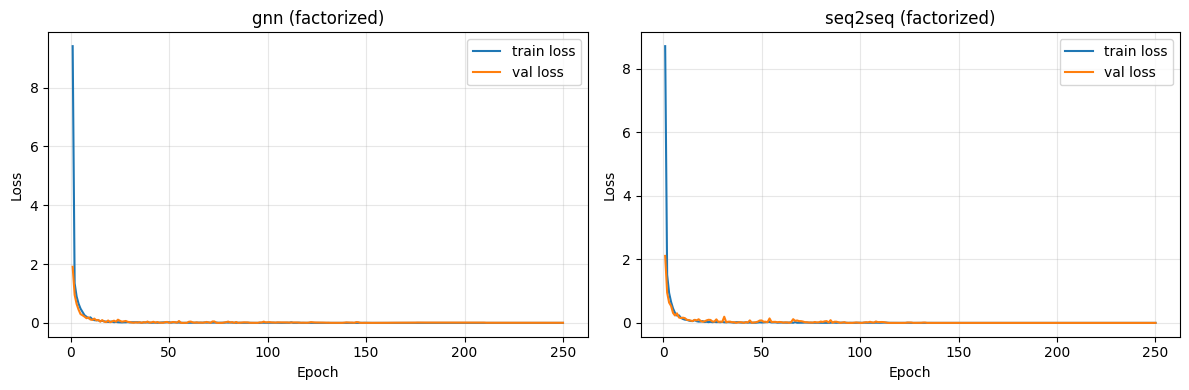

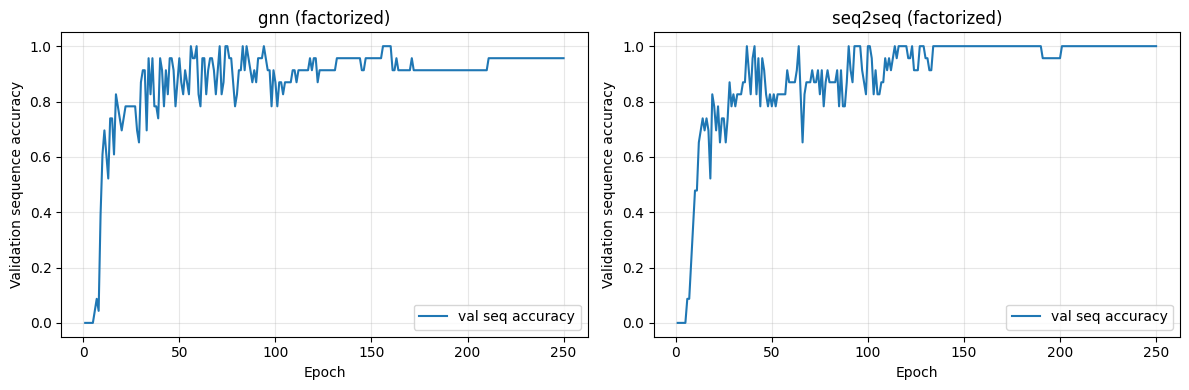

PosixPath('/kaggle/working/accuracy_curves/factorized_accuracy_curves.png')

In [6]:
factorized_results, factorized_histories = run_suite(TARGET_VARIANT_FACTORIZED)
display(factorized_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)
plot_suite_accuracies(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)


## Raw String Runs


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Using device: cuda
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234

  Amp2Sq Training: raw_string_gnn
  Encoder: gnn
  Source view: physics-tagged amplitude sequence
  Target variant: raw_string
  Decoder representation: postfix
  Grammar const

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 0001 | train 8.6134 | val 2.9117 | 6.1s
Epoch 0002 | train 2.1917 | val 1.6161 | 12.2s
Epoch 0003 | train 1.6887 | val 1.3408 | 18.4s
Epoch 0004 | train 1.4097 | val 1.1265 | 24.5s
Epoch 0005 | train 1.1942 | val 0.8853 | 30.6s
Epoch 0010 | train 0.6317 | val 0.4255 | 61.4s
Epoch 0020 | train 0.1325 | val 0.0401 / seq 0.565 | improved | 193.4s
Epoch 0030 | train 0.0399 | val 0.0047 | 255.0s
Epoch 0040 | train 0.0068 | val 0.0039 / seq 0.913 | improved | 365.9s
Epoch 0050 | train 0.0029 | val 0.0044 | 427.3s
Epoch 0060 | train 0.0030 | val 0.0048 / seq 0.870 | 538.6s
Epoch 0070 | train 0.0030 | val 0.0057 | 601.3s
Epoch 0080 | train 0.0054 | val 0.0057 / seq 0.826 | 711.9s
Epoch 0090 | train 0.0039 | val 0.0029 | 773.3s
Epoch 0100 | train 0.0022 | val 0.0030 / seq 0.913 | improved | 884.4s
Epoch 0110 | train 0.0011 | val 0.0032 | 946.0s
Epoch 0120 | train 0.0121 | val 0.0071 / seq 0.739 | 1057.8s
Epoch 0130 | train 0.0020 | val 0.0059 | 1119.1s
Epoch 0140 | train 0.0056 | val 0.00

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,raw_string,gnn,gnn,1242,42,0.875000
1,raw_string,seq2seq,seq2seq,1242,42,0.791667


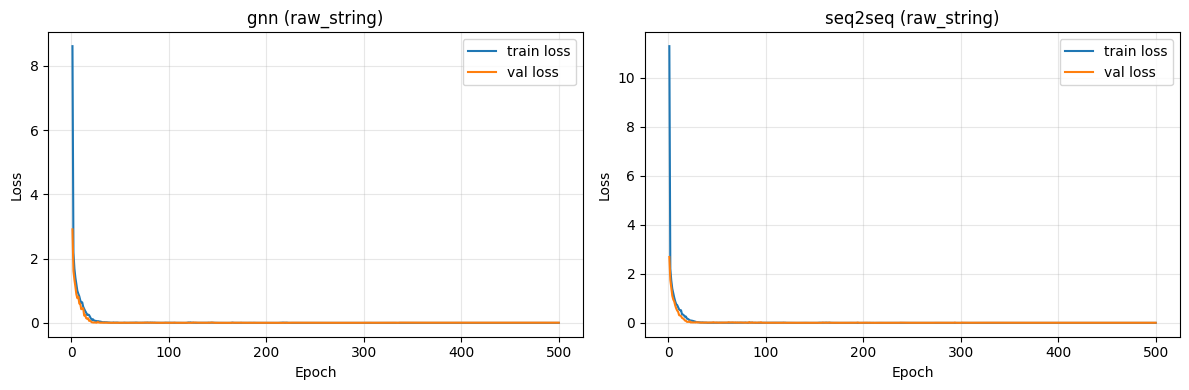

PosixPath('/kaggle/working/loss_curves/raw_string_loss_curves.png')

In [7]:
raw_results, raw_histories = run_suite(TARGET_VARIANT_RAW_STRING)
display(raw_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_RAW_STRING, raw_results, raw_histories)


## Final Summary


In [8]:
final_summary_df = pd.concat([factorized_results, raw_results], ignore_index=True)
summary_small = final_summary_df[SUMMARY_COLUMNS]
summary_json = working_dir / "ablation_summary_all.json"
summary_md = working_dir / "ablation_summary_all.md"
summary_small.to_json(summary_json, orient="records", indent=2)
write_markdown_table(summary_small, summary_md, "Final Summary")
display(summary_small)
print(f"Saved summary to {summary_json}")
print(f"Saved markdown summary to {summary_md}")


,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,gnn,gnn,128,42,1.000000
1,factorized,seq2seq,seq2seq,128,42,0.958333
2,raw_string,gnn,gnn,1242,42,0.875000
3,raw_string,seq2seq,seq2seq,1242,42,0.791667


Saved summary to /kaggle/working/ablation_summary_all.json
Saved markdown summary to /kaggle/working/ablation_summary_all.md


## Observation

What I notice here is that the tree-level QCD 2-to-2 dataset closes to a small finite family of simplified `color_factor` terms and `denominator` forms. 

The `color_factor` classes are:

```text
16/9
2
2/3
3/4
64/27
8/3
```

The denominator classes are:

```text
(2*m_b^2 + reg_prop + 2*s_12)^2
(2*m_b^2 + reg_prop - 2*s_13)^2
(2*m_c^2 + reg_prop + 2*s_12)^2
(2*m_c^2 + reg_prop - 2*s_13)^2
(2*m_d^2 + reg_prop + 2*s_12)^2
(2*m_d^2 + reg_prop - 2*s_13)^2
(2*m_s^2 + reg_prop + 2*s_12)^2
(2*m_s^2 + reg_prop - 2*s_13)^2
(2*m_t^2 + reg_prop + 2*s_12)^2
(2*m_t^2 + reg_prop - 2*s_13)^2
(2*m_u^2 + reg_prop + 2*s_12)^2
(2*m_u^2 + reg_prop - 2*s_13)^2
(reg_prop + 2*s_12)^2
(reg_prop - 2*s_13)^2
(reg_prop - 2*s_23)^2
```

For the QCD notebooks, that observation lines up with the usual color-basis and Casimir-basis perspective. The finite factor side comes from a restricted set of basis combinations in the present 2-to-2 tree-level scope `{C_F^2, C_A^2, C_F*C_A}`, while the denominator side comes from the equally restricted propagator topologies in the diagrams.

If I extend this later, the interesting question is how these observed finite families change once I move beyond 2-to-2 tree level, allow more external legs, or include loops. We can explore methods including Casimir-basis etc. 

References:
- [L. Dixon, *Calculating Scattering Amplitudes Efficiently* (1996)](https://arxiv.org/abs/hep-ph/9601359)
- [V. Del Duca, L. Dixon, F. Maltoni, *New Color Decompositions for Gauge Amplitudes at Tree and Loop Level* (1999)](https://arxiv.org/abs/hep-ph/9910563)
- [H. Johansson, A. Ochirov, *Color-Kinematics Duality for QCD Amplitudes* (2015)](https://arxiv.org/abs/1507.00332)
- [S. Catani, *The Singular Behaviour of QCD Amplitudes at Two-Loop Order* (1998)](https://arxiv.org/abs/hep-ph/9802439)


In [9]:
observation_summary_df = observation_summary(data_dir)
observation_json = working_dir / "observation_summary.json"
observation_md = working_dir / "observation_summary.md"
observation_summary_df.to_json(observation_json, orient="records", indent=2)
write_markdown_table(observation_summary_df, observation_md, "Observation Summary")
display(observation_summary_df)
print(f"Saved observation summary to {observation_json}")
print(f"Saved observation markdown to {observation_md}")


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,num_samples,unique_color_factors,unique_denominators
0,234,6,15


Saved observation summary to /kaggle/working/observation_summary.json
Saved observation markdown to /kaggle/working/observation_summary.md


## Thank you!
Please mail me at sreenandan.shashidharan@gmail.com or at 24JE0701@iitism.ac.in if anything is amiss. I sincerely apologise in advance. 